# Lab 12 — LSTM and GRU Models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-12-lstm-gru-models.ipynb)

This lab accompanies **Chapter 12: LSTM and GRU Models** in the Math NLP book.

A vanilla recurrent neural network updates one hidden state by

$$
h_t = \tanh(W_x e_t + W_h h_{t-1} + b_h).
$$

This is mathematically clean, but long sequences create long products of Jacobian matrices. These products can shrink or explode. LSTM and GRU models introduce **gates**: vectors with entries between $0$ and $1$ that control how much information is kept, forgotten, written, or revealed.

The central idea of this lab is that gates create a more stable memory path.

## What you will learn

By the end of this lab, you should be able to:

1. explain the vanishing-gradient problem using scalar and vector recurrences;
2. interpret sigmoid gates as coordinatewise interpolation weights;
3. implement the LSTM forward equations from scratch;
4. implement the GRU forward equations from scratch;
5. compare ungated and gated memory on a long-range dependency task;
6. visualize forget/update gates and effective memory length;
7. connect gate values to NLP tasks where early tokens must be remembered.

This notebook is designed for independent study. The programming is intentionally small and transparent so that the mathematical structure remains visible.

## 0. Setup

We use only NumPy, pandas, and matplotlib. No external dataset is required.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(12)

## 1. Why vanilla RNNs have trouble with long memory

Consider the scalar linear recurrence

$$
h_t = a h_{t-1} + b u_t.
$$

If an input enters at time $s$, its contribution to $h_T$ contains the factor

$$
a^{T-s}.
$$

Therefore:

- if $|a|<1$, early information decays exponentially;
- if $|a|>1$, early information may explode;
- if $|a|$ is near $1$, early information may persist.

This scalar model is not a full RNN, but it captures the same mathematical difficulty: information and gradients must pass through repeated multiplicative factors.

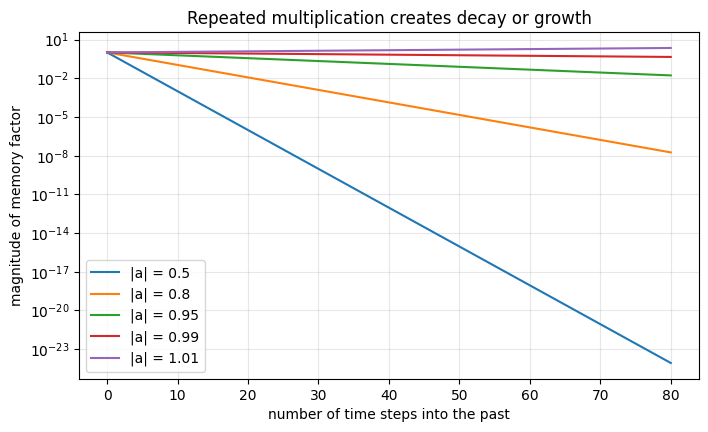

,memory factor a,steps until factor falls to 1/2
0,0.50,1.000000
1,0.80,3.106284
2,0.90,6.578813
3,0.95,13.513407
4,0.98,34.309618
5,0.99,68.967564


In [2]:
steps = np.arange(0, 81)
a_values = [0.50, 0.80, 0.95, 0.99, 1.01]

plt.figure(figsize=(8, 4.5))
for a in a_values:
    plt.plot(steps, np.abs(a) ** steps, label=f"|a| = {a}")
plt.yscale("log")
plt.xlabel("number of time steps into the past")
plt.ylabel("magnitude of memory factor")
plt.title("Repeated multiplication creates decay or growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

rows = []
for a in [0.50, 0.80, 0.90, 0.95, 0.98, 0.99]:
    half_life = math.log(0.5) / math.log(a)
    rows.append({"memory factor a": a, "steps until factor falls to 1/2": half_life})

pd.DataFrame(rows)

### Interpretation

A memory factor of $0.8$ may look close to $1$, but after $40$ steps it becomes $0.8^{40}\approx 0.00013$. A gated model learns factors that can stay close to $1$ when long memory is useful, and close to $0$ when old information should be erased.

## 2. Sigmoid gates as coordinatewise control variables

A gate is usually computed with the logistic sigmoid function

$$
\sigma(z) = \frac{1}{1+e^{-z}}.
$$

Because $0 < \sigma(z) < 1$, a gate can be used as an interpolation weight. For vectors $a,b \in R^r$ and a gate $g\in(0,1)^r$,

$$
g \odot a + (1-g)\odot b
$$

chooses a coordinatewise mixture of $a$ and $b$.

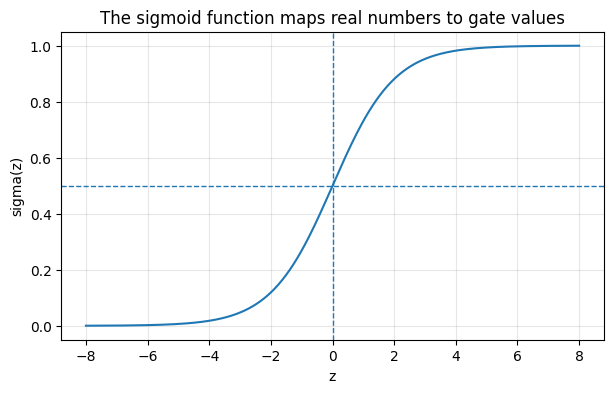

,coordinate,gate,old_memory,new_candidate,g * old + (1-g) * new
0,0,0.95,2.0,-2.0,1.80
1,1,0.75,-1.0,3.0,0.00
2,2,0.25,0.5,1.5,1.25
3,3,0.05,4.0,-1.0,-0.75


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 400)
plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid(z))
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("z")
plt.ylabel("sigma(z)")
plt.title("The sigmoid function maps real numbers to gate values")
plt.grid(True, alpha=0.3)
plt.show()

old_memory = np.array([2.0, -1.0, 0.5, 4.0])
new_candidate = np.array([-2.0, 3.0, 1.5, -1.0])
gate = np.array([0.95, 0.75, 0.25, 0.05])
mixture = gate * old_memory + (1 - gate) * new_candidate

pd.DataFrame({
    "coordinate": np.arange(len(gate)),
    "gate": gate,
    "old_memory": old_memory,
    "new_candidate": new_candidate,
    "g * old + (1-g) * new": mixture,
})

### Check your understanding

In the table above, a gate near $1$ mostly keeps the old memory. A gate near $0$ mostly chooses the new candidate. In LSTM and GRU models, this idea is applied repeatedly at every token.

## 3. A minimal gated-memory recurrence

Before writing the full LSTM equations, study a simplified memory recurrence:

$$
c_t = f_t c_{t-1} + i_t \widetilde c_t.
$$

Here:

- $c_t$ is the memory value;
- $f_t$ is a forget gate;
- $i_t$ is an input gate;
- $\widetilde c_t$ is a candidate value to write.

If $f_t$ is close to $1$, old memory is preserved. If $f_t$ is close to $0$, old memory is erased.

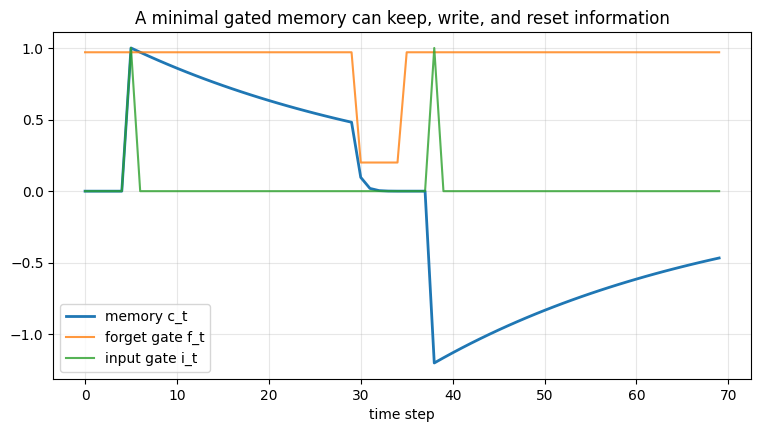

,t,forget_gate,input_gate,candidate,memory
0,0,0.97,0.0,0.0,0.000000
5,5,0.97,1.0,1.0,1.000000
10,10,0.97,0.0,0.0,0.858734
29,29,0.97,0.0,0.0,0.481417
30,30,0.20,0.0,0.0,0.096283
34,34,0.20,0.0,0.0,0.000154
38,38,0.97,1.0,-1.2,-1.199864
50,50,0.97,0.0,0.0,-0.832516
69,69,0.97,0.0,0.0,-0.466719


In [4]:
T = 70
candidate = np.zeros(T)
input_gate = np.zeros(T)
forget_gate = np.ones(T) * 0.97

# Write information at two moments.
candidate[5] = 1.0
input_gate[5] = 1.0
candidate[38] = -1.2
input_gate[38] = 1.0

# A controlled reset period.
forget_gate[30:35] = 0.20

c = np.zeros(T)
for t in range(T):
    prev = c[t-1] if t > 0 else 0.0
    c[t] = forget_gate[t] * prev + input_gate[t] * candidate[t]

plt.figure(figsize=(9, 4.5))
plt.plot(c, label="memory c_t", linewidth=2)
plt.plot(forget_gate, label="forget gate f_t", alpha=0.8)
plt.plot(input_gate, label="input gate i_t", alpha=0.8)
plt.xlabel("time step")
plt.title("A minimal gated memory can keep, write, and reset information")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({
    "t": np.arange(T),
    "forget_gate": forget_gate,
    "input_gate": input_gate,
    "candidate": candidate,
    "memory": c,
}).iloc[[0, 5, 10, 29, 30, 34, 38, 50, 69]]

The sharp drop around time steps $30$ to $34$ happens because the forget gate is temporarily small. This is the basic mechanism that lets a gated recurrent model decide when to keep old information and when to reset it.

## 4. LSTM equations from scratch

An LSTM has two state vectors:

$$
h_t \in R^r, \qquad c_t \in R^r.
$$

The hidden state $h_t$ is exposed to later layers. The cell state $c_t$ is the memory path.

Given input embedding $e_t \in R^m$, previous hidden state $h_{t-1}\in R^r$, and previous cell state $c_{t-1}\in R^r$, the LSTM computes

$$
f_t = \sigma(W_f e_t + U_f h_{t-1}+b_f),
$$

$$
i_t = \sigma(W_i e_t + U_i h_{t-1}+b_i),
$$

$$
o_t = \sigma(W_o e_t + U_o h_{t-1}+b_o),
$$

$$
\widetilde c_t = \tanh(W_c e_t + U_c h_{t-1}+b_c),
$$

then updates

$$
c_t = f_t\odot c_{t-1} + i_t\odot \widetilde c_t,
$$

$$
h_t = o_t\odot \tanh(c_t).
$$

The forget gate $f_t$ controls the direct memory path.

In [5]:
def init_lstm_params(vocab_size, emb_dim=5, hidden_dim=4, scale=0.35, forget_bias=1.0, seed=0):
    local_rng = np.random.default_rng(seed)
    params = {"E": local_rng.normal(0, scale, size=(vocab_size, emb_dim))}
    for name in ["f", "i", "o", "c"]:
        params[f"W_{name}"] = local_rng.normal(0, scale, size=(hidden_dim, emb_dim))
        params[f"U_{name}"] = local_rng.normal(0, scale, size=(hidden_dim, hidden_dim))
        params[f"b_{name}"] = np.zeros(hidden_dim)
    params["b_f"] = np.ones(hidden_dim) * forget_bias
    return params

def lstm_forward(ids, params):
    E = params["E"]
    hidden_dim = params["U_f"].shape[0]
    h = np.zeros(hidden_dim)
    c = np.zeros(hidden_dim)
    records = []
    states = []
    for t, idx in enumerate(ids):
        e = E[idx]
        f = sigmoid(params["W_f"] @ e + params["U_f"] @ h + params["b_f"])
        i = sigmoid(params["W_i"] @ e + params["U_i"] @ h + params["b_i"])
        o = sigmoid(params["W_o"] @ e + params["U_o"] @ h + params["b_o"])
        c_tilde = np.tanh(params["W_c"] @ e + params["U_c"] @ h + params["b_c"])
        c = f * c + i * c_tilde
        h = o * np.tanh(c)
        records.append({
            "t": t,
            "token_id": idx,
            "mean_forget_gate": f.mean(),
            "mean_input_gate": i.mean(),
            "mean_output_gate": o.mean(),
            "cell_norm": np.linalg.norm(c),
            "hidden_norm": np.linalg.norm(h),
        })
        states.append({"h": h.copy(), "c": c.copy(), "f": f.copy(), "i": i.copy(), "o": o.copy()})
    return h, c, pd.DataFrame(records), states

toy_vocab = ["remember", "the", "first", "word", "after", "many", "tokens", "now"]
toy_stoi = {w: i for i, w in enumerate(toy_vocab)}
toy_ids = [toy_stoi[w] for w in ["remember", "the", "first", "word", "after", "many", "tokens", "now"]]

lstm_params = init_lstm_params(len(toy_vocab), emb_dim=5, hidden_dim=4, seed=12)
h_final, c_final, lstm_table, lstm_states = lstm_forward(toy_ids, lstm_params)

print("Final hidden state h_T:", h_final)
print("Final cell state c_T:", c_final)
lstm_table

Final hidden state h_T: [-0.1051  0.1119 -0.0913 -0.0443]
Final cell state c_T: [-0.1901  0.2069 -0.1458 -0.0952]


,t,token_id,mean_forget_gate,mean_input_gate,mean_output_gate,cell_norm,hidden_norm
0,0,0,0.776056,0.485361,0.515794,0.219150,0.121990
1,1,1,0.721762,0.481340,0.561126,0.211154,0.112250
2,2,2,0.681790,0.496160,0.508610,0.272249,0.145645
3,3,3,0.772392,0.493262,0.481153,0.388486,0.194706
4,4,4,0.711051,0.501446,0.498434,0.377112,0.187128
5,5,5,0.664297,0.512290,0.485125,0.254357,0.130744
6,6,6,0.732666,0.495971,0.508689,0.298025,0.136629
7,7,7,0.775439,0.480320,0.551137,0.330592,0.184015


### Dimension check

If $e_t\in R^m$ and $h_t,c_t\in R^r$, then every gate is in $R^r$. The four matrices $W_f,W_i,W_o,W_c$ have shape $r\times m$, while $U_f,U_i,U_o,U_c$ have shape $r\times r$.

In [6]:
shape_rows = []
for key, value in lstm_params.items():
    shape_rows.append({"parameter": key, "shape": value.shape})
pd.DataFrame(shape_rows)

,parameter,shape
0,E,"(8, 5)"
1,W_f,"(4, 5)"
2,U_f,"(4, 4)"
3,b_f,"(4,)"
4,W_i,"(4, 5)"
5,U_i,"(4, 4)"
6,b_i,"(4,)"
7,W_o,"(4, 5)"
8,U_o,"(4, 4)"
9,b_o,"(4,)"


## 5. GRU equations from scratch

A gated recurrent unit has one state vector $h_t\in R^r$. It uses two main gates:

$$
z_t = \sigma(W_z e_t + U_z h_{t-1}+b_z),
$$

$$
r_t = \sigma(W_r e_t + U_r h_{t-1}+b_r).
$$

The reset gate $r_t$ controls how much old state is used in the candidate:

$$
\widetilde h_t = \tanh(W_n e_t + U_n(r_t\odot h_{t-1}) + b_n).
$$

The update gate $z_t$ controls interpolation between the old state and the new candidate:

$$
h_t = z_t\odot h_{t-1} + (1-z_t)\odot \widetilde h_t.
$$

In this convention, $z_t$ close to $1$ means **keep old state**.

In [7]:
def init_gru_params(vocab_size, emb_dim=5, hidden_dim=4, scale=0.35, update_bias=1.0, seed=0):
    local_rng = np.random.default_rng(seed)
    params = {"E": local_rng.normal(0, scale, size=(vocab_size, emb_dim))}
    for name in ["z", "r", "n"]:
        params[f"W_{name}"] = local_rng.normal(0, scale, size=(hidden_dim, emb_dim))
        params[f"U_{name}"] = local_rng.normal(0, scale, size=(hidden_dim, hidden_dim))
        params[f"b_{name}"] = np.zeros(hidden_dim)
    params["b_z"] = np.ones(hidden_dim) * update_bias
    return params

def gru_forward(ids, params):
    E = params["E"]
    hidden_dim = params["U_z"].shape[0]
    h = np.zeros(hidden_dim)
    records = []
    states = []
    for t, idx in enumerate(ids):
        e = E[idx]
        z = sigmoid(params["W_z"] @ e + params["U_z"] @ h + params["b_z"])
        r = sigmoid(params["W_r"] @ e + params["U_r"] @ h + params["b_r"])
        h_tilde = np.tanh(params["W_n"] @ e + params["U_n"] @ (r * h) + params["b_n"])
        h = z * h + (1 - z) * h_tilde
        records.append({
            "t": t,
            "token_id": idx,
            "mean_update_gate": z.mean(),
            "mean_reset_gate": r.mean(),
            "candidate_norm": np.linalg.norm(h_tilde),
            "hidden_norm": np.linalg.norm(h),
        })
        states.append({"h": h.copy(), "z": z.copy(), "r": r.copy(), "h_tilde": h_tilde.copy()})
    return h, pd.DataFrame(records), states

gru_params = init_gru_params(len(toy_vocab), emb_dim=5, hidden_dim=4, seed=21)
gru_h_final, gru_table, gru_states = gru_forward(toy_ids, gru_params)

print("Final GRU hidden state h_T:", gru_h_final)
gru_table

Final GRU hidden state h_T: [ 0.0879 -0.1221 -0.1048  0.0296]


,t,token_id,mean_update_gate,mean_reset_gate,candidate_norm,hidden_norm
0,0,0,0.714089,0.550558,0.287848,0.089082
1,1,1,0.729871,0.459950,0.240650,0.069077
2,2,2,0.705902,0.493223,0.556067,0.205978
3,3,3,0.707053,0.549245,0.876574,0.372852
4,4,4,0.726330,0.502010,0.361574,0.285680
5,5,5,0.725054,0.503457,0.328096,0.280906
6,6,6,0.715849,0.476700,0.424081,0.241961
7,7,7,0.735638,0.512725,0.158691,0.185729


## 6. LSTM versus GRU: structure comparison

Both models use gates, but they organize memory differently.

| Model | State variables | Main gates | Memory mechanism |
|---|---|---|---|
| LSTM | $h_t$ and $c_t$ | forget, input, output | explicit cell state $c_t$ with controlled writing and forgetting |
| GRU | $h_t$ only | update, reset | hidden state is directly interpolated between old state and candidate |

The LSTM has a more explicit memory cell. The GRU is simpler and often faster.

In [8]:
comparison = pd.DataFrame([
    {"model": "vanilla RNN", "state_count": 1, "gates": "none", "keep mechanism": "fixed recurrent dynamics"},
    {"model": "LSTM", "state_count": 2, "gates": "forget, input, output", "keep mechanism": "cell state c_t with forget gate"},
    {"model": "GRU", "state_count": 1, "gates": "update, reset", "keep mechanism": "update-gate interpolation"},
])
comparison

,model,state_count,gates,keep mechanism
0,vanilla RNN,1,none,fixed recurrent dynamics
1,LSTM,2,"forget, input, output",cell state c_t with forget gate
2,GRU,1,"update, reset",update-gate interpolation


## 7. A controlled long-range dependency experiment

Now we create a tiny synthetic NLP-style task.

Each sequence starts with either token `A` or token `B`. The label is determined only by this first token:

$$
A \mapsto 0, \qquad B \mapsto 1.
$$

All later tokens are distractors. A model must carry information from the first token to the end of the sequence.

We compare three simplified memory mechanisms:

1. vanilla recurrence with factor $a$;
2. LSTM-like memory with forget factor $f$;
3. GRU-like memory with update factor $z$.

This is not a full trained network. It is a mathematical diagnostic showing how different memory factors behave as sequence length grows.

In [9]:
def make_long_memory_dataset(n=1000, length=50, seed=0):
    local_rng = np.random.default_rng(seed)
    labels = local_rng.integers(0, 2, size=n)
    first_values = np.where(labels == 1, 1.0, -1.0)
    # Later distractor inputs have mean zero and should not determine the label.
    distractors = local_rng.normal(0, 0.12, size=(n, length - 1))
    X = np.column_stack([first_values, distractors])
    return X, labels

X, y = make_long_memory_dataset(n=5, length=12, seed=1)
pd.DataFrame(X).round(3).assign(label=y)

,0,1,2,3,4,5,6,7,8,9,10,11,label
0,-1.0,-0.156,0.109,0.054,-0.064,0.070,0.044,0.035,0.003,0.066,-0.088,-0.020,0
1,1.0,-0.058,0.072,0.005,-0.035,-0.094,-0.031,0.001,-0.033,0.155,0.121,-0.325,1
2,1.0,-0.227,-0.021,-0.051,0.026,0.026,0.254,-0.133,-0.045,0.245,0.078,0.080,1
3,1.0,-0.062,-0.198,0.020,0.013,-0.147,-0.082,-0.009,-0.113,-0.012,0.011,0.004,1
4,-1.0,-0.061,0.071,0.107,0.039,-0.098,0.088,-0.060,0.105,-0.129,0.110,-0.002,0


In [10]:
def vanilla_memory_features(X, a=0.85):
    h = np.zeros(X.shape[0])
    for t in range(X.shape[1]):
        h = a * h + X[:, t]
    return h

def lstm_like_memory_features(X, f=0.98, input_after_first=0.05):
    c = np.zeros(X.shape[0])
    for t in range(X.shape[1]):
        i = 1.0 if t == 0 else input_after_first
        c = f * c + i * X[:, t]
    return c

def gru_like_memory_features(X, z=0.98, input_after_first=0.05):
    h = np.zeros(X.shape[0])
    for t in range(X.shape[1]):
        candidate = X[:, t]
        keep = 0.0 if t == 0 else z
        write = 1.0 if t == 0 else input_after_first
        # This simplified GRU-like update keeps old state and admits a small amount of new candidate.
        h = keep * h + write * (1 - keep) * candidate if t > 0 else candidate
    return h

def accuracy_from_sign(feature, labels):
    pred = (feature > 0).astype(int)
    return (pred == labels).mean()

lengths = [5, 10, 20, 40, 80, 120]
rows = []
for L in lengths:
    X, y = make_long_memory_dataset(n=3000, length=L, seed=100 + L)
    h_rnn = vanilla_memory_features(X, a=0.82)
    h_lstm = lstm_like_memory_features(X, f=0.985, input_after_first=0.02)
    h_gru = gru_like_memory_features(X, z=0.985, input_after_first=0.02)
    rows.append({
        "sequence_length": L,
        "vanilla_RNN_like_accuracy": accuracy_from_sign(h_rnn, y),
        "LSTM_like_accuracy": accuracy_from_sign(h_lstm, y),
        "GRU_like_accuracy": accuracy_from_sign(h_gru, y),
        "vanilla_first_token_factor": 0.82 ** (L - 1),
        "gated_first_token_factor": 0.985 ** (L - 1),
    })

results = pd.DataFrame(rows)
results

,sequence_length,vanilla_RNN_like_accuracy,LSTM_like_accuracy,GRU_like_accuracy,vanilla_first_token_factor,gated_first_token_factor
0,5,0.992333,1.0,1.0,4.521218e-01,0.941337
1,10,0.787333,1.0,1.0,1.676196e-01,0.872823
2,20,0.541333,1.0,1.0,2.303898e-02,0.750392
3,40,0.487000,1.0,1.0,4.352515e-04,0.554642
4,80,0.504000,1.0,1.0,1.553439e-07,0.303014
5,120,0.501667,1.0,1.0,5.544322e-11,0.165543


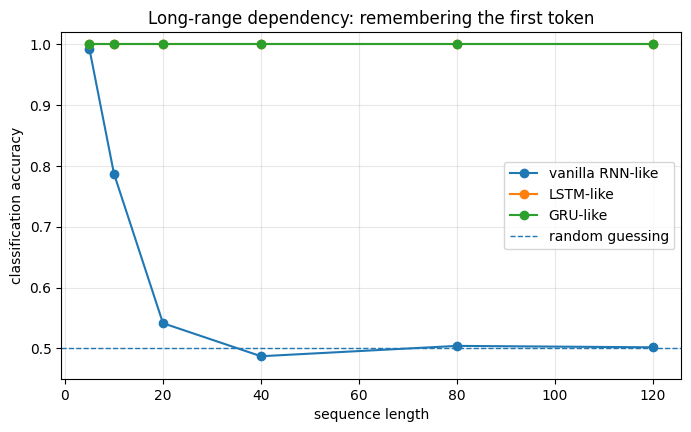

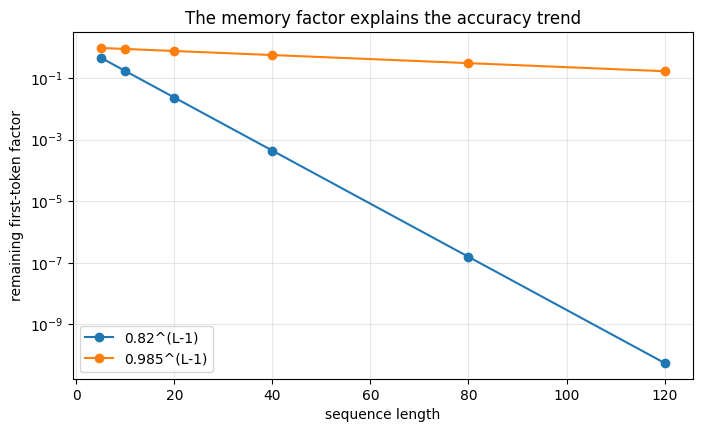

In [11]:
plt.figure(figsize=(8, 4.5))
plt.plot(results["sequence_length"], results["vanilla_RNN_like_accuracy"], marker="o", label="vanilla RNN-like")
plt.plot(results["sequence_length"], results["LSTM_like_accuracy"], marker="o", label="LSTM-like")
plt.plot(results["sequence_length"], results["GRU_like_accuracy"], marker="o", label="GRU-like")
plt.axhline(0.5, linestyle="--", linewidth=1, label="random guessing")
plt.xlabel("sequence length")
plt.ylabel("classification accuracy")
plt.title("Long-range dependency: remembering the first token")
plt.ylim(0.45, 1.02)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(results["sequence_length"], results["vanilla_first_token_factor"], marker="o", label="0.82^(L-1)")
plt.plot(results["sequence_length"], results["gated_first_token_factor"], marker="o", label="0.985^(L-1)")
plt.yscale("log")
plt.xlabel("sequence length")
plt.ylabel("remaining first-token factor")
plt.title("The memory factor explains the accuracy trend")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Important interpretation

This experiment does not prove that every LSTM or GRU will outperform every RNN. It shows why learned gates are useful: they allow the model to choose memory factors close to $1$ when information should persist. In real training, the model must learn these gates from data.

## 8. Effective memory length of a gate

If a forget gate has constant scalar value $f$, then a memory contribution $k$ steps in the past is multiplied by

$$
f^k.
$$

The half-life solves

$$
f^k = \frac{1}{2}.
$$

Thus

$$
k = \frac{\log(1/2)}{\log(f)}.
$$

A small change from $f=0.95$ to $f=0.99$ can greatly increase memory length.

In [12]:
gate_values = np.array([0.50, 0.70, 0.80, 0.90, 0.95, 0.97, 0.98, 0.99, 0.995])
half_lives = np.log(0.5) / np.log(gate_values)

half_life_df = pd.DataFrame({
    "gate_value": gate_values,
    "half_life_steps": half_lives,
    "factor_after_50_steps": gate_values ** 50,
    "factor_after_100_steps": gate_values ** 100,
})
half_life_df

,gate_value,half_life_steps,factor_after_50_steps,factor_after_100_steps
0,0.500,1.000000,8.881784e-16,7.888609e-31
1,0.700,1.943358,1.798465e-08,3.234477e-16
2,0.800,3.106284,1.427248e-05,2.037036e-10
3,0.900,6.578813,5.153775e-03,2.656140e-05
4,0.950,13.513407,7.694498e-02,5.920529e-03
5,0.970,22.756573,2.180654e-01,4.755251e-02
6,0.980,34.309618,3.641697e-01,1.326196e-01
7,0.990,68.967564,6.050061e-01,3.660323e-01
8,0.995,138.282573,7.783126e-01,6.057704e-01


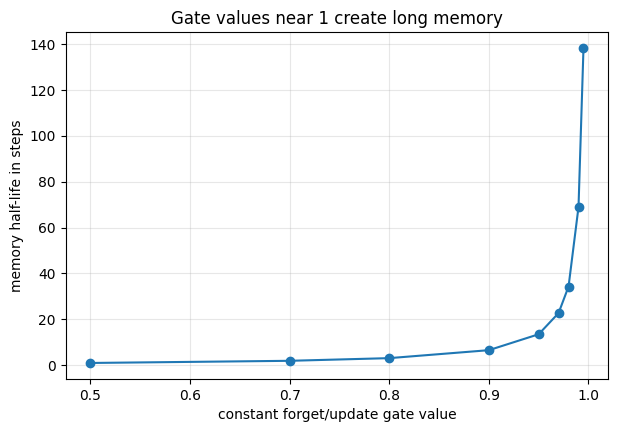

In [13]:
plt.figure(figsize=(7, 4.5))
plt.plot(gate_values, half_lives, marker="o")
plt.xlabel("constant forget/update gate value")
plt.ylabel("memory half-life in steps")
plt.title("Gate values near 1 create long memory")
plt.grid(True, alpha=0.3)
plt.show()

## 9. Inspecting gate trajectories

The following code visualizes the mean gate values from the random LSTM and GRU forward passes above. A trained model would produce gates adapted to the task; here we are inspecting the mechanics of the equations.

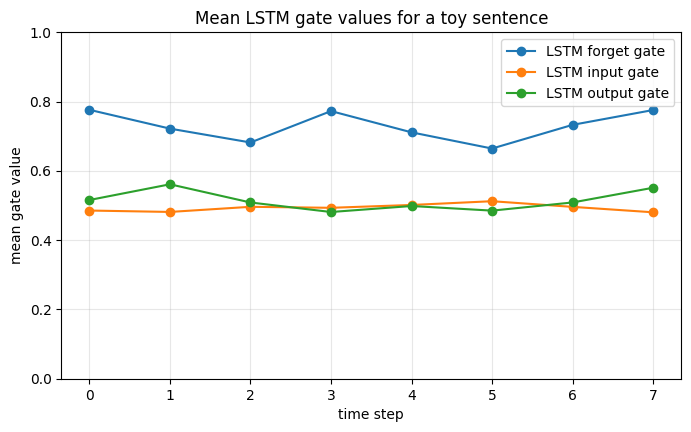

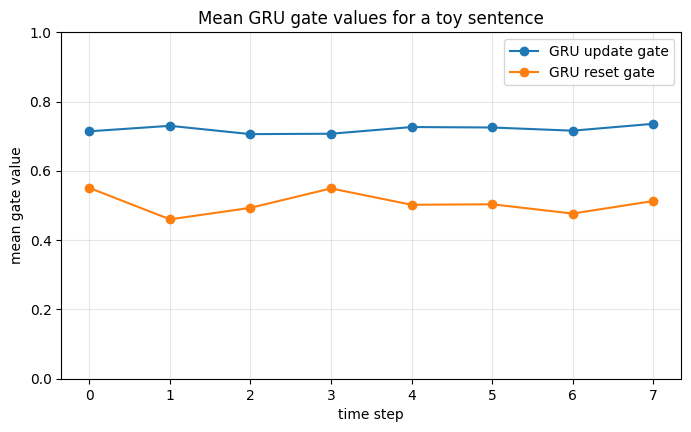

In [14]:
plt.figure(figsize=(8, 4.5))
plt.plot(lstm_table["t"], lstm_table["mean_forget_gate"], marker="o", label="LSTM forget gate")
plt.plot(lstm_table["t"], lstm_table["mean_input_gate"], marker="o", label="LSTM input gate")
plt.plot(lstm_table["t"], lstm_table["mean_output_gate"], marker="o", label="LSTM output gate")
plt.xlabel("time step")
plt.ylabel("mean gate value")
plt.title("Mean LSTM gate values for a toy sentence")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(gru_table["t"], gru_table["mean_update_gate"], marker="o", label="GRU update gate")
plt.plot(gru_table["t"], gru_table["mean_reset_gate"], marker="o", label="GRU reset gate")
plt.xlabel("time step")
plt.ylabel("mean gate value")
plt.title("Mean GRU gate values for a toy sentence")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Optional extension: train a tiny gated classifier in Colab

The previous sections used transparent NumPy simulations. In a larger course project, you may train an LSTM or GRU using a deep learning library.

The cell below is intentionally skipped by default so that the core lab runs quickly everywhere. In Google Colab, set `RUN_OPTIONAL_TORCH = True` to train small PyTorch LSTM and GRU classifiers on the synthetic long-memory task.

In [15]:
RUN_OPTIONAL_TORCH = False

if RUN_OPTIONAL_TORCH:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F

    torch.manual_seed(12)

    vocab_size = 14
    seq_len = 35
    n_train = 512
    n_test = 256

    def make_torch_data(n, length, seed=0):
        local_rng = np.random.default_rng(seed)
        X = local_rng.integers(2, vocab_size, size=(n, length))
        y = local_rng.integers(0, 2, size=n)
        X[:, 0] = y  # first token stores the label
        return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long)

    X_train, y_train = make_torch_data(n_train, seq_len, seed=1)
    X_test, y_test = make_torch_data(n_test, seq_len, seed=2)

    class TorchSequenceClassifier(nn.Module):
        def __init__(self, cell_type="LSTM", emb_dim=8, hidden_dim=12):
            super().__init__()
            self.emb = nn.Embedding(vocab_size, emb_dim)
            if cell_type == "LSTM":
                self.rnn = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
            elif cell_type == "GRU":
                self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)
            else:
                self.rnn = nn.RNN(emb_dim, hidden_dim, nonlinearity="tanh", batch_first=True)
            self.out = nn.Linear(hidden_dim, 2)

        def forward(self, x):
            z = self.emb(x)
            output, hidden = self.rnn(z)
            final = output[:, -1, :]
            return self.out(final)

    def train_model(cell_type, epochs=15):
        model = TorchSequenceClassifier(cell_type=cell_type)
        opt = torch.optim.Adam(model.parameters(), lr=0.02)
        for epoch in range(epochs):
            opt.zero_grad()
            logits = model(X_train)
            loss = F.cross_entropy(logits, y_train)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        with torch.no_grad():
            test_acc = (model(X_test).argmax(dim=1) == y_test).float().mean().item()
        return test_acc

    for cell_type in ["RNN", "LSTM", "GRU"]:
        print(cell_type, "test accuracy:", train_model(cell_type))
else:
    print("Optional PyTorch training cell skipped. Set RUN_OPTIONAL_TORCH = True in Colab to run it.")

Optional PyTorch training cell skipped. Set RUN_OPTIONAL_TORCH = True in Colab to run it.


## 11. Exercises

### Exercise 1: Change the forget gate

In Section 7, change the LSTM-like forget factor from `0.985` to `0.95`, `0.99`, and `0.995`. What happens to accuracy as sequence length increases?

### Exercise 2: Change distractor strength

In `make_long_memory_dataset`, increase the distractor standard deviation from `0.12` to `0.30`. Which memory mechanism is most affected?

### Exercise 3: Compare LSTM and GRU equations

Write one paragraph comparing the roles of the LSTM forget gate $f_t$ and the GRU update gate $z_t$. In the convention used here, what does it mean when each gate is close to $1$?

### Exercise 4: Dimension checking

Set `emb_dim=6` and `hidden_dim=7` in the LSTM initialization. Confirm the shapes of all matrices. Explain why $W_f$ and $U_f$ have different shapes.

### Exercise 5: Gate saturation

Evaluate `sigmoid(z)` for $z=-10, -5, 0, 5, 10$. Why can gates that are too close to $0$ or $1$ create optimization difficulties?

## 12. Mini-project: design a memory task

Create your own synthetic sequence classification problem where the correct label depends on a token far in the past.

Suggested examples:

1. The first token determines the label.
2. The first and last token together determine the label.
3. The label depends on whether a special token appeared anywhere in the sequence.
4. The label depends on whether token `not` appears before a sentiment word.

For your mini-project:

1. define the data-generating process;
2. explain why bag-of-words may or may not solve it;
3. compare at least two memory mechanisms;
4. make one plot;
5. write a short conclusion about the role of gates.

## 13. AI-assisted reflection prompts

You may use an AI assistant to help your thinking, but you should verify all mathematical statements yourself.

Try these prompts:

1. "Explain the LSTM forget gate as a coordinatewise derivative path."
2. "Compare a GRU update gate with exponential smoothing in time series."
3. "Give an example of an NLP task where early tokens must be remembered for many steps."
4. "Why does a gate value close to one improve long-range memory but also risk retaining irrelevant information?"

Write your own final explanation in your own words.

## Summary

In this lab, you saw that:

- vanilla RNN memory depends on repeated multiplication;
- sigmoid gates are coordinatewise control variables;
- LSTM models use an explicit cell state $c_t$ with forget, input, and output gates;
- GRU models use update and reset gates to control a single hidden state;
- gate values close to $1$ create long effective memory;
- gated recurrences are useful for NLP tasks with long-range dependencies.

The next chapters move from recurrent memory to attention, where a model can connect distant tokens more directly.